 <center> <h1> Indian_Kids_Screen_Time Case study </h1> </center>

**Note:**
- In this experiment, we will perform several operations on a CSV file using the NumPy, Pandas, Matplotlib, and Seaborn libraries.
- Our main focus will be on key operations that are commonly used in these libraries.
- The following operations will be conducted on the CSV file:
  - Importing the necessary libraries.
  - Loading the dataset into the experiment.
  - Understanding the data in the file.
  - Performing data cleaning and visualization operations.
  - Preparing the data for further processes in the Data Science Life Cycle.

**Experiment Link** --> https://colab.research.google.com/drive/1Cg6g1UeZ26MhzixjQXtky5gtB8PTuDPQ?usp=sharing

**Data set link** -->https://drive.google.com/file/d/1co8hEwy_frdK_UzYooDQNjwpV9UnneAc/view?usp=sharing

In [1]:
# Importing the required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading the data_set.
df = pd.read_csv("/content/Indian_Kids_Screen_Time.csv")

In [3]:
#Understanding the data_set.
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


- Observing the data set for how many types of data are contained in the CSV_file.

- By this, we understand the dataset's composition and the different data types present in the file.

In [5]:
df.shape
#using this, we find out the shape of the dataset.

(9712, 8)

In [6]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


- Using the describe() function, we can obtain the total average, count, maximum, and minimum values of the data.

In [7]:
# We are now going to perform some data cleaning operations on the file.
df.isnull().sum()

,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,3218
Urban_or_Rural,0


- We are checking for null values in the data.
- result: 'Health_Impacts' column has '3218' null values.

In [8]:
df["Health_Impacts"].unique()

array(['Poor Sleep, Eye Strain', 'Poor Sleep', nan, 'Poor Sleep, Anxiety',
       'Poor Sleep, Obesity Risk', 'Eye Strain', 'Obesity Risk',
       'Anxiety', 'Poor Sleep, Anxiety, Obesity Risk',
       'Eye Strain, Obesity Risk', 'Eye Strain, Anxiety, Obesity Risk',
       'Anxiety, Obesity Risk', 'Poor Sleep, Eye Strain, Obesity Risk',
       'Poor Sleep, Eye Strain, Anxiety',
       'Poor Sleep, Eye Strain, Anxiety, Obesity Risk',
       'Eye Strain, Anxiety'], dtype=object)

- We have filled the null values in the 'Health_Impacts' column with the mode value.

In [9]:
df['Health_Impacts'].mode()

,Health_Impacts
0,Poor Sleep


In [10]:
df = df.fillna('Poor Sleep')

In [11]:
df.isnull().sum()

,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,0
Urban_or_Rural,0


- We are filling the null values in the dataset using the mode value from the 'mode()' and 'fillna()' function.

In [12]:
df.duplicated().sum()

np.int64(47)

- We are identifying duplicate values in the dataset and removing them to ensure data accuracy.

In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

- we dropen the duplicate values from the dataset

In [15]:
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,Poor Sleep,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


In [16]:
# comparing the columns

avg_screentime_rural = df[(df["Avg_Daily_Screen_Time_hr"] > 5) & (df ["Urban_or_Rural"] == 'Rural')]

In [17]:
avg_screentime_rural.sort_values(['Age'],ascending=True)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
292,8,Female,9.35,Smartphone,True,0.55,Anxiety,Rural
9690,8,Female,5.57,Smartphone,True,0.44,Eye Strain,Rural
9211,8,Male,5.38,Tablet,True,0.49,Obesity Risk,Rural
542,8,Male,5.67,Smartphone,True,0.52,"Poor Sleep, Eye Strain",Rural
479,8,Male,7.20,Smartphone,True,0.60,Poor Sleep,Rural
...,...,...,...,...,...,...,...,...
9525,18,Male,5.22,Smartphone,True,0.47,"Poor Sleep, Anxiety",Rural
167,18,Female,6.59,Laptop,True,0.39,Poor Sleep,Rural
91,18,Female,6.30,Tablet,True,0.39,Poor Sleep,Rural
9683,18,Male,5.11,Smartphone,True,0.39,Obesity Risk,Rural


In [18]:
avg_screentime_rural.value_counts().sum()

np.int64(966)

- We analysed the "Avg_Daily_Screen_Time_hr" column in relation to the "Urban_or_Rural" column to determine how many children in rural areas exceed five hours of screen time.
- To find this value, we compared the two columns using the following functions: 1. `sort_values()`, 2. `value_counts()`, and 3. `sum()`.
- The total number of children with more than five hours of screen time is 966.

In [19]:
avg_screentime_urban = df[(df["Avg_Daily_Screen_Time_hr"] > 5) & (df ["Urban_or_Rural"] == 'Urban')]

In [20]:
avg_screentime_urban.sort_values(['Age'],ascending=True)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
4461,8,Female,7.40,TV,True,0.60,"Poor Sleep, Anxiety",Urban
9581,8,Male,10.18,Smartphone,True,0.43,Obesity Risk,Urban
241,8,Male,5.36,Tablet,True,0.56,Poor Sleep,Urban
198,8,Male,6.29,Tablet,True,0.49,Poor Sleep,Urban
192,8,Male,6.34,TV,True,0.51,Poor Sleep,Urban
...,...,...,...,...,...,...,...,...
6917,18,Male,6.91,Smartphone,True,0.42,Poor Sleep,Urban
2389,18,Male,5.54,Laptop,True,0.43,Anxiety,Urban
2381,18,Female,5.05,Laptop,True,0.32,Eye Strain,Urban
6872,18,Male,5.07,Laptop,True,0.50,Poor Sleep,Urban


In [21]:
avg_screentime_urban.value_counts().sum()

np.int64(2306)

- We analysed the "Avg_Daily_Screen_Time_hr" column in relation to the "Urban_or_Rural" column to determine how many children in urban areas exceed five hours of screen time.
- To find this value, we compared the two columns using the following functions: 1. `sort_values()`, 2. `value_counts()`, and 3. `sum()`.
- The total number of children with more than five hours of screen time is '2306'.

In [22]:
mini = avg_screentime_urban[avg_screentime_urban["Age"] <= 12]

In [23]:
mini

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
23,12,Female,6.78,TV,True,0.33,Eye Strain,Urban
34,11,Female,5.34,Smartphone,True,0.40,"Poor Sleep, Eye Strain",Urban
36,10,Male,11.68,TV,True,0.47,Poor Sleep,Urban
43,9,Male,7.61,TV,True,0.50,Poor Sleep,Urban
...,...,...,...,...,...,...,...,...
9677,9,Male,5.18,Smartphone,True,0.55,"Anxiety, Obesity Risk",Urban
9679,11,Female,6.02,Smartphone,True,0.46,Poor Sleep,Urban
9685,9,Male,5.58,Tablet,True,0.46,Poor Sleep,Urban
9696,12,Female,5.05,Smartphone,True,0.41,"Poor Sleep, Eye Strain",Urban


In [24]:
mini.sort_values('Age',ascending=True).reset_index()

,index,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,9581,8,Male,10.18,Smartphone,True,0.43,Obesity Risk,Urban
1,9410,8,Female,6.29,Tablet,True,0.52,Eye Strain,Urban
2,9443,8,Male,6.30,TV,True,0.56,Poor Sleep,Urban
3,9446,8,Female,6.94,Tablet,True,0.41,Poor Sleep,Urban
4,443,8,Female,8.46,Smartphone,True,0.46,Poor Sleep,Urban
...,...,...,...,...,...,...,...,...,...
1046,5468,12,Female,5.27,Tablet,True,0.49,"Poor Sleep, Eye Strain",Urban
1047,5486,12,Male,5.94,Laptop,True,0.45,Poor Sleep,Urban
1048,5675,12,Male,5.11,TV,True,0.47,"Poor Sleep, Obesity Risk",Urban
1049,5691,12,Female,5.33,Smartphone,True,0.35,"Eye Strain, Anxiety",Urban


In [25]:
mini.value_counts().sum()

np.int64(1051)

- We analysed the "Avg_Daily_Screen_Time_hr" column in relation to the "Age" column to determine how many children in urban areas exceed five hours of screen time and below or equal 12 years.

/tmp/ipykernel_1610/4041848655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age',y='Avg_Daily_Screen_Time_hr',data=mini,palette='dark')


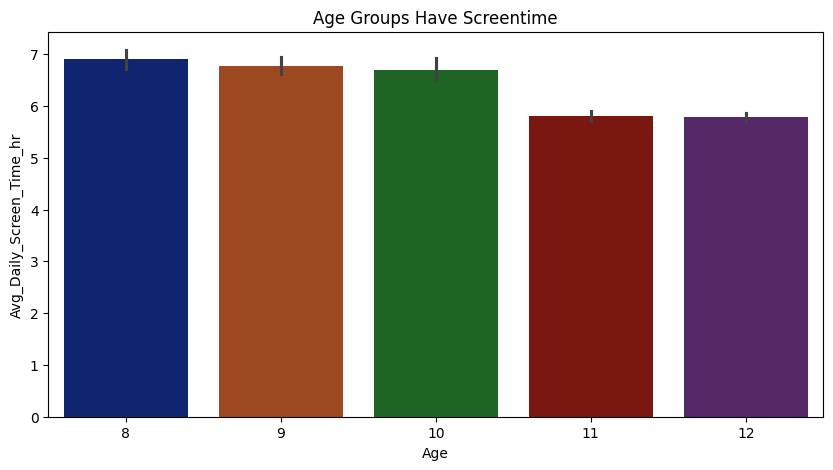

In [26]:
# Compareing the columns.
plt.figure(figsize=(10,5))
sns.barplot(x='Age',y='Avg_Daily_Screen_Time_hr',data=mini,palette='dark')
plt.xlabel('Age')
plt.ylabel('Avg_Daily_Screen_Time_hr')
plt.title('Age Groups Have Screentime')
plt.show()